# Q5: Model complexity
This week we worked with model complexity, and we used an example of predicting growth of a tree sort. 

### Focus a: Linear least squares problem for model fitting
While you might have some inductive bias for the relationship between input and output, can be difficult to tell what underlying function suit data best. 
Look at scatter plot in 01-polynomial_regression (W07). Is relationship linear or maybe polynomial? 
For this issue, we can use the least squares problem and its solution. We have some training data, and we need to find a good regression model, with the minimum loss. 
We split our data into test and train (80-20 or 70-30) so we can evaluate the model on unseen data after training. We then train the model, using different model complexities, by creating design matrices. For this, we use a mapping, that transforms a single value into a kernel vector. Example for a 3rd order polynomial kernel:

$$ \phi(x) = \begin{bmatrix}1\\ x \\ x^2 \\ x^3 \end{bmatrix} $$

This kernel vector is transposed and used as rows in our design matrix. This helps us express a non-linear model as a linear function between the kernel vector and the model parameters, which means we can solve using linear least squares method. 

Using the pseudoinvserse, we can find the best model parameters that minimize the squared difference between actual labels and predicted labels.


### Focus b: Data quality, uncertainty, overfitting and underfitting
In the real world, we don't have data that perfectly follows some underlying function. In the first exercise, we want to train a model to predict price based on the lot size of a house. Looking at the data, it's difficult to get a good idea of the underlying function (we don't have much inductive bias). When fitting different regression models to the training data, and evaluating on test data, we're looking at generalisation, bias and variance. 

Generalisation is how well the model performs on unseen data. It does not matter if we have a model with 0 prediction errors on the training data, if it makes completely wrong predictions on new data. Generalisation error is the difference between training error and testing error. If both errors are high, and the model systematically deviates, it means we have a high bias. Usaully due to using a too simple function. This is underfitting. If training error is low, but testing error is high, we have a high variance, and we might have overfit the model. Overfitting the model means that we use a too complex underlying function, which starts fitting specifically to the training data instead of the underlying trend in the data. Underfitting is using a too simple model, that cannot describe the relationship between input and output. Look at bottom graphs in 01-polynomial_regression. We want to find the sweet spot where we don't underfit and we don't overfit. 

In week 6, we made a model for gaze estimation, using our own collected data. Conditions such as light, camera stability and quality, subject stillness and distractions affected the data quality. See task 7 in 01-data-preprocessing for line pattern, where we have some general random noise, as well as some outliers. The outliers can be categorized as additive, as they are localised, infrequent and have a larger magnitude than rest of the data. If we use a too complex function for the gaze estimation, it would lead to overfitting as the model would fit to the noise. 

### Focus c: Model ability to generalise to unseen data. Data evaluation, train-test split, cross-validation and performance metrics
A model's ability to generalise on unseen data can be measured by the generalisation error, which is the difference between the training error and the testing error. We want a model that has a low error in both, such that it performs well on unseen data. Different factors can affect this generalisation error. The generalisation error can be decomposed into bias, variance and error that we cannot remove due to noise. Bias is a systemtic error, where predictions systematically deviate. It usually means that the underlying function is too simple, and we get high training and testing errors. Variance is how much the error varies based on the data. Usually means overfitting. 

To be able to evaluate a models ability to generalise, we need to split the data into training and test data. Here it is done with 70-30 split. Important to be able to test on unseen data. 

Look at last graph in this exercise, where we have fitted models of different complexities. We have a low bias, but a high variance for the higher complexities, and both a high bias and high variance for linear regression. 

Notice that for this train-test split, the last 30% is used for testing. But what if that part of data is not representative? Or maybe it represents most of the trend of the data. We can use cross validation for this. Here we would split the data into K folds, let's say 5 folds. Then for each different order polynomial, we iterate 5 times, using 4 folds for training and 1 for testing. And then we summarise the performance metrics from testing. This takes a little longer, but we don't have to worry about what data to use for testing. Also a good idea to do this multiple times over different K values.

# Model Complexity and Overfitting

**Overview**
In this exercise you will experiment with the impact of model complexity (higher order polynomial) and how it relates to Occam's Razor. 


<article class="message">
    <div class="message-body">
        <strong>List of tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#poly_re">Task 1:  Polynomial regression</a>
            </li>
            <li>
            <a href="#occam_train">Task 2: Train and evaluate linear models with po…</a>
            </li>
            <li>
            <a href="#plot_results">Task 3: Plot the polynomials (models)</a>
            </li>
            <li>
            <a href="#reflection">Task 4: Reflection</a>
            </li>
            <li>
            <a href="#Different_data_func">Task 5: Changing the data generating function</a>
            </li>
        </ul>
    </div>
</article>

<div style="float: right; width: 50%; justify-content: start" class="block is-clearfix">

<div class="has-text-centered">
<figure class="image is-inline-block" >

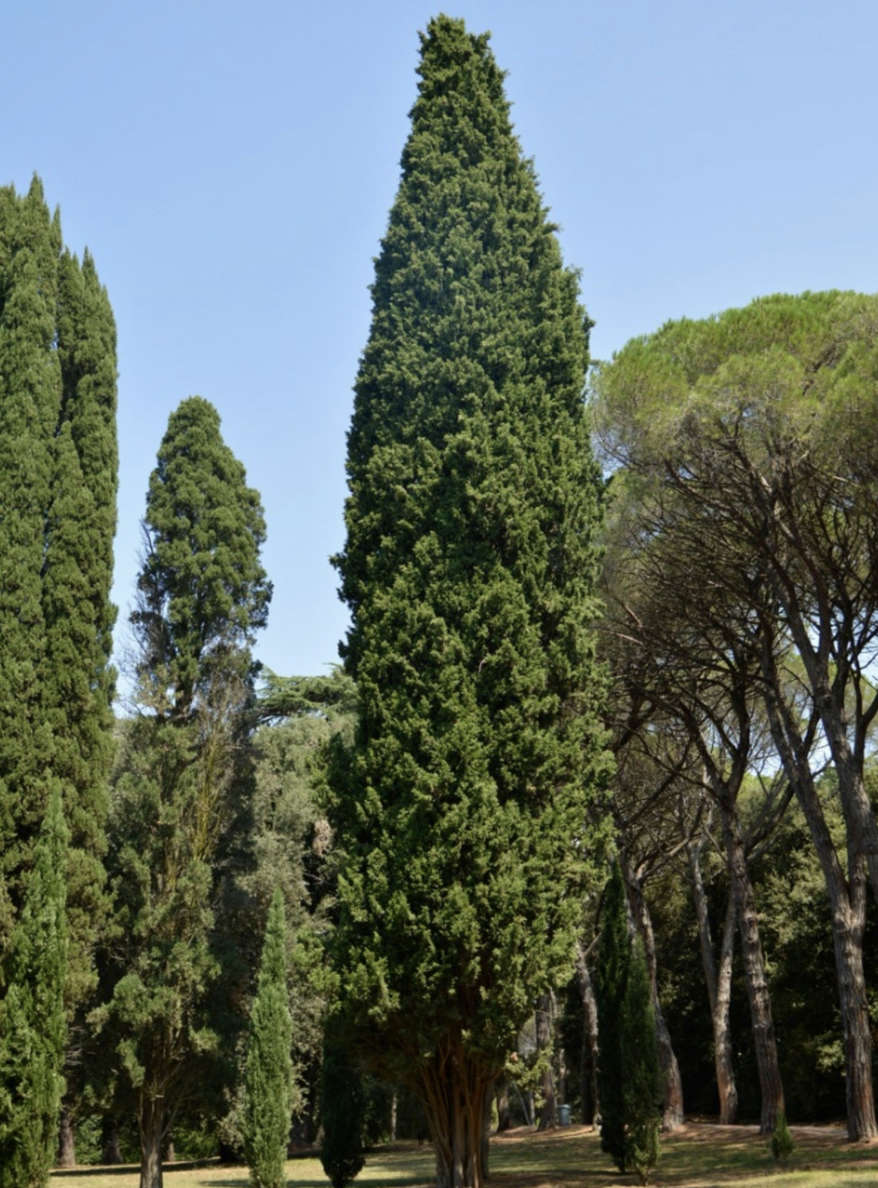


</figure>
</div>


</div>

This exercise is about making a regression model to predict the growth of Thuja Green Giant trees. You have to help the scientists decide which polynomial order best represents the training data to estimate future growth. To determine the optimal fit (model parameters), another group of researchers have provided you with  observation of height of their Thuja Green Giant trees from years later than currently observed by your team (`X_test`
 and `y_test`
). You will use this to choose the optimal model representing the growth of the Thuja Green Giant.
## Data
The following cell constructs and shows the data for the exercise. The data simulates growth (in meters) of one of the fastest growing trees, the Thuja Green Giant, each year. Scientists have observed and reported the growth of the tree for 7 years (`X_train`
 and `y_train`
), and now want to predict the future growth. 
The objective is to assist in making predictions based on this data. Additional data from another group has been provided to validate the hypothesis.
The scientists assume a polynomial relationship. 


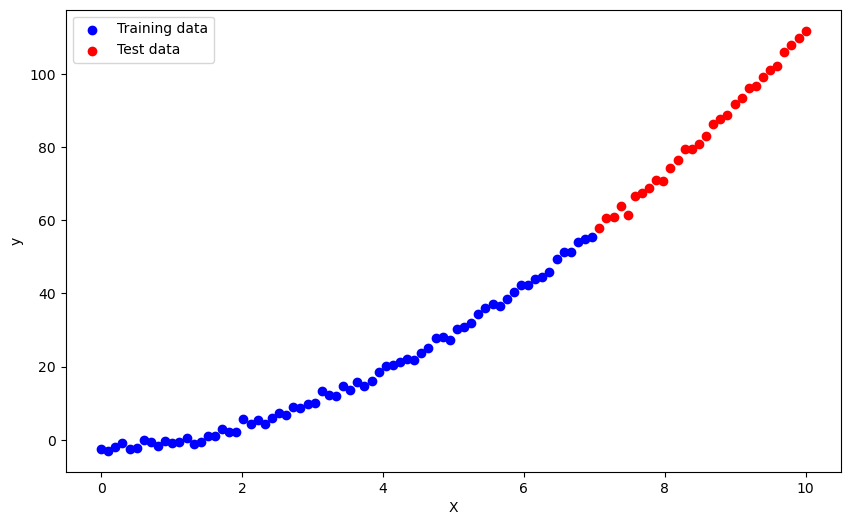

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_samples = 100
X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_true = X.ravel()**2 + 1.5 * X.ravel() - 3
noise = np.random.normal(0, 1, n_samples)
y = y_true + noise

# Split the data into training and test sets
split_index = int(0.7 * n_samples)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()


---
**Task 1 (easy):  Polynomial regression👩‍💻**
1. In this exercise you may reuse polynomial regression using least squares
 from the previous exercise, or use the `PolynomialFeatures()`
 method from the [scikit-learn library](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
 to implement the `polynomial_regression()`
 method in the cell below. 


---

In [4]:
def polynomial_regression(X, y, degree):
    """
    Create and train a model of desired order and use it to predict the growth of the trees.

    :param X: Vector of combined observed years).
    :param y: Vector of combined observed height.
    :param degree: Degree of the model.
    
    :return: Vector containing prediction for training data, vector containing prediction for test data.
    """
    poly = PolynomialFeatures(degree)

    split_index = int(0.7 * n_samples)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train = y[:split_index]

    poly_features_train = poly.fit_transform(X_train)
    poly_features_test = poly.fit_transform(X_test)

    poly_reg_model = LinearRegression()

    poly_reg_model.fit(poly_features_train, y_train)

    return poly_reg_model.predict(poly_features_train), poly_reg_model.predict(poly_features_test)
    



---
**Task 2 (easy): Train and evaluate linear models with polynomial features👩‍💻**
1. Use the function `polynomial_regression`
 to perform polynomial regression for each order defined in the `degrees`
 variable and predict the outcome for both the test and training data. 
2. Implement the function `compute_mse`
 that based on the predictions of a model and the ground truth targets returns the _mean-squared-error_.


$$ MSE = \frac{1}{m}\sum_{i=1}^{m}(f_{\mathbf{w}}(x_{i})-y_{i})^2$$

**Hint**
You may save some time by modifying the implementation of the `rmse`
 function from the previous exercise.

3. For each polynomial model calculate the _mean-squared-error_ for both the training and test data (use `polynomial_regression`
 and `compute_mse`
).


---

In [21]:
def compute_mse(y_true, y_pred):
    """Compute Mean Squared Error between true and predicted values."""
    #write code/solution here ... 
    return ((y_pred - y_true)**2).mean()
    
# Train and evaluate linear models with different polynomial features

degrees = [1, 2, 3, 4, 5, 6]
train_pred = []
test_pred = []
train_error = []
test_error = []

for i, degree in enumerate(degrees):
    poly_train, poly_test = polynomial_regression(X, y, degree)

    train_pred.insert(i, poly_train) 
    test_pred.insert(i, poly_test)
    mse_train = compute_mse(y_train, poly_train)
    mse_test = compute_mse(y_test, poly_test)
    train_error.insert(i, mse_train)
    test_error.insert(i, mse_test)


    


---
**Task 3 (easy): Plot the polynomials (models)👩‍💻**
Run the cell below to:
1. Plot the data so that training and test data have different colors.
2. Plot the predictions of the polynomial models over the scatter plot showing the given data. Perform this for both the training and test sets using X as input.


---

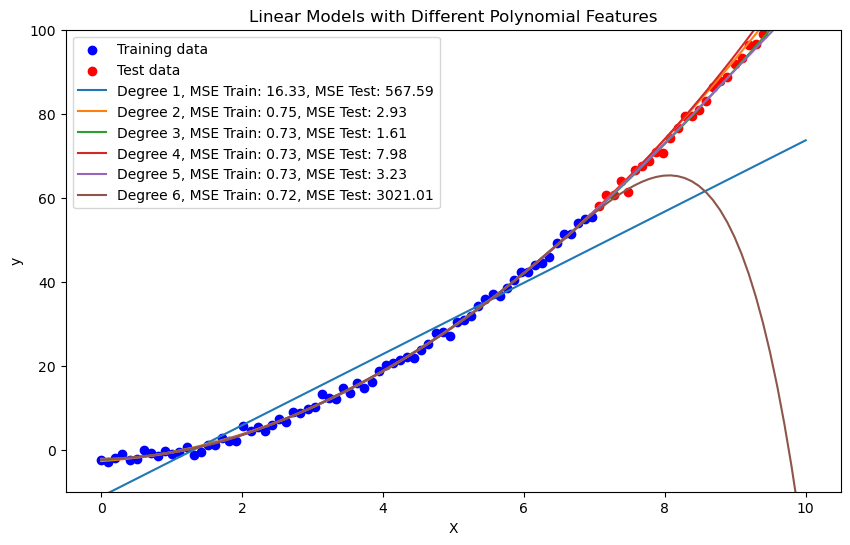

(0.0, 30.0)

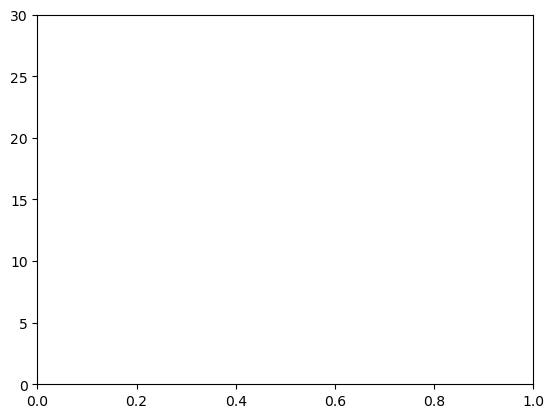

In [26]:
# Plot the results

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')

for i, degree in enumerate(degrees):
    plt.plot(X, np.concatenate((train_pred[i],test_pred[i])), label=f'Degree {degree}, MSE Train: {train_error[i]:.2f}, MSE Test: {test_error[i]:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.ylim(-10,100)
plt.legend()
plt.title('Linear Models with Different Polynomial Features')
plt.show()
# Insert code for question 1
# The following line keep axis fixed in a plot
plt.ylim(0,30)
# Insert code for question 2


---
**Task 4 (medium): Reflection💡**
Reflect on:
1. Which model had the best performance  on the training data?
2. Which model had the best performance  on the test data?
3. How does the complexity (degree) of the model affect the performance on the training and test data?
4. Which model(s) shows signs of overfitting? How can you tell?


---

In [0]:
# Write reflection here

#1. the 6th degree polynomial fits the training data best
#2. the 1st degree polynomial (linear) fits the test data best
#3. the higher the degree, the better it fits the training data but the error increases for the test data
#4. definitely the 6th degree. 
#   I would argue the 5th and 4th degree, and maybe the 3rd degree as well, as it has a low error on the training data, but a high error on test data. 
#   It therefore has a high variability and does not generalize well. 


---
**Task 5 (medium): Changing the data generating function👩‍💻💡**
How do the results change if the underlying function generating the data was changed to a 2. order polynomial, so that it e.g. simulates bacteria growth instead? 
1. Re-generate the data by replacing `y_true`
 with $y=f(x)=x^2+1.5x-3$ in the data generation step, and rerun the other code blocks.
2. Does it still make sense to follow the strategy of Occam's razor?


---

In [0]:
# Write reflection
# The degree that fits both the training and test data best is strangely the 3rd polynomial, if we use the MSE to decide. 
# but if we follow Occam's razor, and choose the simplest function that still provides good predictions, that would be the 2nd order polynomial, which is also the underlying true function. 